In [1]:
import psycopg
import pandas as pd
import numpy as np
import re

from psycopg.rows import tuple_row
from psycopg import connect
from psycopg import sql as psql

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def execute_sql(sql, params=None):
    """
    For creating tables, inserting into tables.
    """
    with psycopg.connect(conninfo) as conn:
        with conn.cursor() as cur:
            cur.execute(sql, params)
        conn.commit()

In [4]:
def query_df(sql, params=None):
    """
    For running queries. Returns pandas dataframe of query ouput.
    """
    with psycopg.connect(conninfo) as conn:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            cols = [d.name for d in cur.description]
            return pd.DataFrame(cur.fetchall(), columns=cols)

In [5]:
tables = [
    "brands", "categories", "ingredients",
    "product_ingredients", "products",
    "reviews", "users", "ingredient_skin_sentiment"
]

for t in tables:
    df = query_df(f"SELECT COUNT(*) AS n FROM {t};")
    print(t, df.iloc[0,0])

brands 367
categories 245
ingredients 16450
product_ingredients 225371
products 8575
reviews 1094477
users 503256
ingredient_skin_sentiment 31333


##### clean skin type column

In [6]:
execute_sql("""
CREATE OR REPLACE VIEW clean_users AS
SELECT *
FROM users
WHERE skin_type IN ('dry','oily','combination','normal');
""")

In [7]:
query_df("""
SELECT skin_type, COUNT(*) AS n
FROM clean_users
GROUP BY skin_type
ORDER BY n DESC;
""")

,skin_type,n
0,combination,241329
1,dry,79778
2,normal,60277
3,oily,54640


##### clean ingredients

In [8]:
# helper tables

# names -> standardized names
execute_sql("""
CREATE TABLE IF NOT EXISTS ingredient_alias_map (
    raw_name TEXT PRIMARY KEY,
    canonical_name TEXT NOT NULL,
    inci_name TEXT,
    source TEXT DEFAULT 'manual',
    notes TEXT
);
""")

# role of canonical ingredients (base, fragrance, preservatives, etc)
execute_sql("""
CREATE TABLE IF NOT EXISTS ingredient_role_map (
    canonical_name TEXT PRIMARY KEY,
    primary_role TEXT,
    is_common_base BOOLEAN DEFAULT FALSE,
    is_active BOOLEAN DEFAULT FALSE,
    is_preservative BOOLEAN DEFAULT FALSE,
    is_fragrance BOOLEAN DEFAULT FALSE,
    is_surfactant BOOLEAN DEFAULT FALSE,
    is_drying_alcohol BOOLEAN DEFAULT FALSE,
    is_essential_oil BOOLEAN DEFAULT FALSE,
    notes TEXT
);
""")

# regulation / risk / allergen flags
execute_sql("""
CREATE TABLE IF NOT EXISTS ingredient_regulation_flags (
    canonical_name TEXT PRIMARY KEY,
    eu_status TEXT,
    us_fda_status TEXT,
    cir_status TEXT,
    risk_group TEXT,
    risk_level TEXT,
    notes TEXT
);
""")

In [9]:
def upsert_df(table_name, df, conflict_col):
    if df.empty:
        print(f"{table_name}: empty")
        return

    cols = list(df.columns)
    placeholders = ", ".join(["%s"] * len(cols))
    col_names = ", ".join(cols)
    update_cols = [c for c in cols if c != conflict_col]
    update_clause = ", ".join([f"{c} = EXCLUDED.{c}" for c in update_cols])

    query = f"""
    INSERT INTO {table_name} ({col_names})
    VALUES ({placeholders})
    ON CONFLICT ({conflict_col})
    DO UPDATE SET {update_clause}
    """

    with psycopg.connect(conninfo) as conn:
        with conn.cursor() as cur:
            for row in df.itertuples(index=False, name=None):
                cur.execute(query, row)
        conn.commit()

    print(f"{table_name}: upserted {len(df)} rows")

In [10]:
top_ingredients_raw = query_df("""
SELECT
    i.name,
    COUNT(DISTINCT pi.product_id) AS product_count
FROM product_ingredients pi
JOIN ingredients i
ON pi.ingredient_id = i.id
GROUP BY i.name
ORDER BY product_count DESC;
""")

top_ingredients_raw.head(30)

,name,product_count
0,Glycerin,3644
1,Phenoxyethanol,3283
2,Linalool,2508
3,Tocopherol,2449
4,Limonene,2443
5,Citric Acid,2170
6,Caprylyl Glycol,2109
7,Butylene Glycol,2078
8,Ethylhexylglycerin,1916
9,Potassium Sorbate,1720


In [11]:
df = top_ingredients_raw.copy()
df.head()

,name,product_count
0,Glycerin,3644
1,Phenoxyethanol,3283
2,Linalool,2508
3,Tocopherol,2449
4,Limonene,2443


In [12]:
def normalize_name(x: str) -> str:
    if pd.isna(x):
        return x

    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)

    # remove annotation 
    x = x.replace("(preservative)", "")
    x = x.replace("(skin-soothing)", "")
    x = x.replace("(skin-replenishing)", "")
    x = x.replace("(pro vitamin b5)", "panthenol")
    x = x.replace("*", "")
    x = x.strip()

    synonym_map = {
        # water
        "water/aqua/eau": "water",
        "aqua/water/eau": "water",
        "aqua": "water",
        "eau": "water",
        "distilled water": "water",

        # fragrance
        "parfum": "fragrance",
        "perfume": "fragrance",
        "parfum (fragrance)": "fragrance",
        "parfum/fragrance": "fragrance",

        # vitamin e
        "tocopherol": "vitamin e",
        "tocopheryl acetate": "vitamin e derivative",
        "tocopherol acetate": "vitamin e derivative",

        # hyaluronic acid
        "sodium hyaluronate": "hyaluronic acid",
        "hydrolyzed hyaluronic acid": "hyaluronic acid",
        "hyaluronic acid": "hyaluronic acid",

        # alcohol
        "alcohol denat.": "denatured alcohol",
        "alcohol denat": "denatured alcohol",
        "sd alcohol 40-b": "denatured alcohol",
        "sd alcohol 40-b (alcohol denat.)": "denatured alcohol",
        "sd alcohol 39-c": "denatured alcohol",

        # plant oils
        "olea europaea (olive) oil": "olive oil",
        "glycine soja (soybean) oil": "soybean oil",
        "helianthus annuus (sunflower) seed oil": "sunflower oil",
        "melaleuca alternifolia (tea tree) leaf oil": "tea tree leaf oil",

        # common case normalization
        "ceramide np": "ceramide np",
        "ceramide ng": "ceramide ng",
        "niacinamide": "niacinamide",
        "panthenol": "panthenol",
        "retinol": "retinol",
        "retinal": "retinal",
        "ascorbic acid": "ascorbic acid",
        "allantoin": "allantoin",
        "allantoin (skin-soothing)": "allantoin",
    }

    return synonym_map.get(x, x)

df["canonical_name"] = df["name"].apply(normalize_name)
df.head(10)

,name,product_count,canonical_name
0,Glycerin,3644,glycerin
1,Phenoxyethanol,3283,phenoxyethanol
2,Linalool,2508,linalool
3,Tocopherol,2449,vitamin e
4,Limonene,2443,limonene
5,Citric Acid,2170,citric acid
6,Caprylyl Glycol,2109,caprylyl glycol
7,Butylene Glycol,2078,butylene glycol
8,Ethylhexylglycerin,1916,ethylhexylglycerin
9,Potassium Sorbate,1720,potassium sorbate


In [13]:
alias_df = df[["name", "canonical_name"]].drop_duplicates().copy()
alias_df = alias_df.rename(columns={"name": "raw_name"})
alias_df["inci_name"] = alias_df["canonical_name"].str.upper()
alias_df["source"] = "seed_manual_v1"
alias_df["notes"] = None

alias_df.head(20)

,raw_name,canonical_name,inci_name,source,notes
0,Glycerin,glycerin,GLYCERIN,seed_manual_v1,None
1,Phenoxyethanol,phenoxyethanol,PHENOXYETHANOL,seed_manual_v1,None
2,Linalool,linalool,LINALOOL,seed_manual_v1,None
3,Tocopherol,vitamin e,VITAMIN E,seed_manual_v1,None
4,Limonene,limonene,LIMONENE,seed_manual_v1,None
5,Citric Acid,citric acid,CITRIC ACID,seed_manual_v1,None
6,Caprylyl Glycol,caprylyl glycol,CAPRYLYL GLYCOL,seed_manual_v1,None
7,Butylene Glycol,butylene glycol,BUTYLENE GLYCOL,seed_manual_v1,None
8,Ethylhexylglycerin,ethylhexylglycerin,ETHYLHEXYLGLYCERIN,seed_manual_v1,None
9,Potassium Sorbate,potassium sorbate,POTASSIUM SORBATE,seed_manual_v1,None


In [14]:
COMMON_BASE_SEED = {
    "water",
    "glycerin",
    "butylene glycol",
    "propylene glycol",
    "propanediol",
    "pentylene glycol",
    "caprylyl glycol",
    "1,2-hexanediol",
    "phenoxyethanol",
    "ethylhexylglycerin",
    "citric acid",
    "sodium hydroxide",
    "xanthan gum",
    "carbomer",
    "dimethicone",
    "lecithin",
    "silica",
    "glyceryl stearate",
    "cetearyl alcohol",
    "cetyl alcohol",
    "caprylic/capric triglyceride",
    "potassium sorbate",
    "sodium benzoate",
    "sodium chloride",
    "disodium edta",
    "mica"
}

COMMON_PATTERN_RULES = [
    r"\bcrosspolymer\b",
    r"\bgum\b",
    r"\bpeg-\d+\b",
    r"\bppg-\d+\b",
    r"\bacrylate\b",
    r"\bpolysorbate\b",
    r"\bbenzoate\b",
    r"\bsorbate\b",
    r"\bchloride\b",
    r"\bhydroxide\b",
    r"\bcitrate\b",
    r"\bedta\b",
    r"\bstearate\b",
    r"\bcellulose\b",
    r"\bsiloxane\b",
    r"\bsilicate\b",
]

ACTIVE_OVERRIDE = {
    "niacinamide",
    "panthenol",
    "retinol",
    "retinal",
    "salicylic acid",
    "ascorbic acid",
    "allantoin",
    "madecassoside",
    "centella asiatica extract",
    "ceramide np",
    "ceramide ng",
    "hyaluronic acid",
    "squalane",
    "magnesium ascorbyl phosphate",
}

def is_common_base(name: str, product_count: int) -> bool:
    if name in ACTIVE_OVERRIDE:
        return False
    if name in COMMON_BASE_SEED:
        return True
    for pat in COMMON_PATTERN_RULES:
        if re.search(pat, name):
            return True
    return False

df["is_common_base"] = df.apply(
    lambda row: is_common_base(row["canonical_name"], row["product_count"]),
    axis=1
)

df[["name", "canonical_name", "product_count", "is_common_base"]].head(30)

,name,canonical_name,product_count,is_common_base
0,Glycerin,glycerin,3644,True
1,Phenoxyethanol,phenoxyethanol,3283,True
2,Linalool,linalool,2508,False
3,Tocopherol,vitamin e,2449,False
4,Limonene,limonene,2443,False
5,Citric Acid,citric acid,2170,True
6,Caprylyl Glycol,caprylyl glycol,2109,True
7,Butylene Glycol,butylene glycol,2078,True
8,Ethylhexylglycerin,ethylhexylglycerin,1916,True
9,Potassium Sorbate,potassium sorbate,1720,True


In [15]:
ACTIVE_SEED = {
    "niacinamide": "barrier/brightening",
    "salicylic acid": "bha/exfoliant",
    "retinol": "retinoid",
    "retinal": "retinoid",
    "hyaluronic acid": "hydration",
    "ceramide np": "barrier",
    "ceramide ng": "barrier",
    "panthenol": "soothing/barrier",
    "allantoin": "soothing",
    "madecassoside": "soothing",
    "centella asiatica extract": "soothing",
    "ascorbic acid": "vitamin c",
    "magnesium ascorbyl phosphate": "vitamin c",
    "squalane": "emollient-support",
}

df["is_active"] = df["canonical_name"].isin(ACTIVE_SEED.keys())
df["active_class"] = df["canonical_name"].map(ACTIVE_SEED)

In [16]:
KR_25_FRAGRANCE_ALLERGENS = {
    "limonene",
    "linalool",
    "citral",
    "geraniol",
    "citronellol",
    "coumarin",
    "eugenol",
    "isoeugenol",
    "amyl cinnamal",
    "benzyl alcohol",
    "benzyl benzoate",
    "benzyl cinnamate",
    "benzyl salicylate",
    "cinnamal",
    "cinnamyl alcohol",
    "farnesol",
    "hexyl cinnamal",
    "hydroxycitronellal",
    "hydroxyisohexyl 3-cyclohexene carboxaldehyde",
    "anisyl alcohol",
    "alpha-isomethyl ionone",
    "oak moss extract",
    "tree moss extract",
    "butylphenyl methylpropional",
    "evernia prunastri extract",
}

EU_BANNED_ALLERGENS = {
    "lilial",
    "lyral"
}

EU_EXTRA_ALLERGEN_HINT = {
    "alpha-damascone",
    "damask rose extract",
}

df["is_kr_fragrance_allergen"] = df["canonical_name"].isin(KR_25_FRAGRANCE_ALLERGENS)
df["is_eu_allergen_hint"] = df["canonical_name"].isin(EU_EXTRA_ALLERGEN_HINT)
df["is_eu_banned_allergen"] = df["canonical_name"].isin(EU_BANNED_ALLERGENS)

df[["name", "canonical_name", "is_kr_fragrance_allergen"]].head(20)

,name,canonical_name,is_kr_fragrance_allergen
0,Glycerin,glycerin,False
1,Phenoxyethanol,phenoxyethanol,False
2,Linalool,linalool,True
3,Tocopherol,vitamin e,False
4,Limonene,limonene,True
5,Citric Acid,citric acid,False
6,Caprylyl Glycol,caprylyl glycol,False
7,Butylene Glycol,butylene glycol,False
8,Ethylhexylglycerin,ethylhexylglycerin,False
9,Potassium Sorbate,potassium sorbate,False


In [17]:
ingredient_skin_cleaner = query_df("""
SELECT
    u.skin_type,
    i.id AS ingredient_id,
    i.name AS ingredient_name,
    COUNT(*) AS review_count,
    COUNT(DISTINCT r.product_id) AS product_count,
    ROUND(AVG(r.rating)::numeric, 3) AS avg_rating
FROM reviews r
JOIN clean_users u
  ON r.user_id = u.id
JOIN product_ingredients pi
  ON r.product_id = pi.product_id
JOIN ingredients i
  ON pi.ingredient_id = i.id
WHERE i.name NOT LIKE '%/%'
  AND i.name NOT LIKE '%,%'
GROUP BY u.skin_type, i.id, i.name
HAVING COUNT(*) >= 100
   AND COUNT(DISTINCT r.product_id) >= 5
ORDER BY u.skin_type, avg_rating DESC;
""")

In [18]:
def assign_risk_group(name: str):
    if name in KR_25_FRAGRANCE_ALLERGENS:
        return "fragrance allergen"
    if name in {"phenoxyethanol", "chlorphenesin", "sodium benzoate", "potassium sorbate"}:
        return "preservative sensitivity"
    if name in {"denatured alcohol", "alcohol"}:
        return "drying alcohol"
    if name in {"salicylic acid", "glycolic acid", "mandelic acid", "lactic acid"}:
        return "acid irritation"
    if name in {"retinol", "retinal"}:
        return "retinoid sensitivity"
    if "oil" in name and name not in {"mineral oil", "squalane", "soybean oil", "sunflower oil", "olive oil"}:
        return "essential oil / botanical oil candidate"
    return None

df["risk_group"] = df["canonical_name"].apply(assign_risk_group)

In [19]:
df.sort_values(["is_common_base", "product_count"], ascending=[False, False]).head(50)

,name,product_count,canonical_name,is_common_base,is_active,active_class,is_kr_fragrance_allergen,is_eu_allergen_hint,is_eu_banned_allergen,risk_group
0,Glycerin,3644,glycerin,True,False,NaN,False,False,False,None
1,Phenoxyethanol,3283,phenoxyethanol,True,False,NaN,False,False,False,preservative sensitivity
5,Citric Acid,2170,citric acid,True,False,NaN,False,False,False,None
6,Caprylyl Glycol,2109,caprylyl glycol,True,False,NaN,False,False,False,None
7,Butylene Glycol,2078,butylene glycol,True,False,NaN,False,False,False,None
8,Ethylhexylglycerin,1916,ethylhexylglycerin,True,False,NaN,False,False,False,None
9,Potassium Sorbate,1720,potassium sorbate,True,False,NaN,False,False,False,preservative sensitivity
10,Dimethicone,1701,dimethicone,True,False,NaN,False,False,False,None
11,Water,1694,water,True,False,NaN,False,False,False,None
12,Sodium Benzoate,1601,sodium benzoate,True,False,NaN,False,False,False,preservative sensitivity


In [20]:
df[df["is_active"]].sort_values("product_count", ascending=False)

,name,product_count,canonical_name,is_common_base,is_active,active_class,is_kr_fragrance_allergen,is_eu_allergen_hint,is_eu_banned_allergen,risk_group
18,Sodium Hyaluronate,1445,hyaluronic acid,False,True,hydration,False,False,False,None
26,Panthenol,1028,panthenol,False,True,soothing/barrier,False,False,False,None
30,Squalane,911,squalane,False,True,emollient-support,False,False,False,None
72,Niacinamide,497,niacinamide,False,True,barrier/brightening,False,False,False,None
110,Salicylic Acid,335,salicylic acid,False,True,bha/exfoliant,False,False,False,acid irritation
120,Allantoin,306,allantoin,False,True,soothing,False,False,False,None
140,Ascorbic Acid,270,ascorbic acid,False,True,vitamin c,False,False,False,None
218,Hyaluronic Acid,175,hyaluronic acid,False,True,hydration,False,False,False,None
220,Ceramide NP,174,ceramide np,False,True,barrier,False,False,False,None
280,Hydrolyzed Hyaluronic Acid,132,hyaluronic acid,False,True,hydration,False,False,False,None


In [21]:
df[df["risk_group"].notna()].sort_values("product_count", ascending=False)

,name,product_count,canonical_name,is_common_base,is_active,active_class,is_kr_fragrance_allergen,is_eu_allergen_hint,is_eu_banned_allergen,risk_group
1,Phenoxyethanol,3283,phenoxyethanol,True,False,NaN,False,False,False,preservative sensitivity
2,Linalool,2508,linalool,False,False,NaN,True,False,False,fragrance allergen
4,Limonene,2443,limonene,False,False,NaN,True,False,False,fragrance allergen
9,Potassium Sorbate,1720,potassium sorbate,True,False,NaN,False,False,False,preservative sensitivity
12,Sodium Benzoate,1601,sodium benzoate,True,False,NaN,False,False,False,preservative sensitivity
...,...,...,...,...,...,...,...,...,...,...
10395,Olive Oil Glyceryth-8 Esters,1,olive oil glyceryth-8 esters,False,False,NaN,False,False,False,essential oil / botanical oil candidate
10397,Olive Oil Peg-8 Esters,1,olive oil peg-8 esters,True,False,NaN,False,False,False,essential oil / botanical oil candidate
10399,Olive Oil Polyglyceryl-6 esters,1,olive oil polyglyceryl-6 esters,False,False,NaN,False,False,False,essential oil / botanical oil candidate
10401,Actinidia Chinensis (Kiwi) Seed Oil,1,actinidia chinensis (kiwi) seed oil,False,False,NaN,False,False,False,essential oil / botanical oil candidate


In [22]:
df_non_base = df[~df["is_common_base"]].copy()
df_non_base.sort_values("product_count", ascending=False).head(50)

,name,product_count,canonical_name,is_common_base,is_active,active_class,is_kr_fragrance_allergen,is_eu_allergen_hint,is_eu_banned_allergen,risk_group
2,Linalool,2508,linalool,False,False,NaN,True,False,False,fragrance allergen
3,Tocopherol,2449,vitamin e,False,False,NaN,False,False,False,None
4,Limonene,2443,limonene,False,False,NaN,True,False,False,fragrance allergen
13,Citronellol,1586,citronellol,False,False,NaN,True,False,False,fragrance allergen
15,Geraniol,1499,geraniol,False,False,NaN,True,False,False,fragrance allergen
17,Tocopheryl Acetate,1454,vitamin e derivative,False,False,NaN,False,False,False,None
18,Sodium Hyaluronate,1445,hyaluronic acid,False,True,hydration,False,False,False,None
20,Citral,1346,citral,False,False,NaN,True,False,False,fragrance allergen
21,Benzyl Alcohol,1257,benzyl alcohol,False,False,NaN,True,False,False,fragrance allergen
26,Panthenol,1028,panthenol,False,True,soothing/barrier,False,False,False,None


In [23]:
def primary_role_from_row(row):
    if row["is_active"]:
        return "active"
    if row["is_kr_fragrance_allergen"]:
        return "fragrance"
    if row["canonical_name"] in {"phenoxyethanol", "sodium benzoate", "potassium sorbate", "ethylhexylglycerin"}:
        return "preservative"
    if row["canonical_name"] in {"cocamidopropyl betaine", "sodium laureth sulfate", "laureth-2", "polysorbate 20", "polysorbate 80"}:
        return "surfactant"
    if row["canonical_name"] in {"denatured alcohol", "alcohol"}:
        return "drying_alcohol"
    if row["risk_group"] == "essential oil / botanical oil candidate":
        return "essential_oil"
    if row["is_common_base"]:
        return "base"
    return None

role_df = df[[
    "canonical_name",
    "is_common_base",
    "is_active",
    "is_kr_fragrance_allergen"
]].drop_duplicates().copy()

role_df["is_preservative"] = role_df["canonical_name"].isin({
    "phenoxyethanol", "sodium benzoate", "potassium sorbate", "ethylhexylglycerin"
})

role_df["is_fragrance"] = (
    role_df["is_kr_fragrance_allergen"] |
    (role_df["canonical_name"] == "fragrance")
)

role_df["is_surfactant"] = role_df["canonical_name"].isin({
    "cocamidopropyl betaine", "sodium laureth sulfate", "laureth-2", "polysorbate 20", "polysorbate 80"
})

role_df["is_drying_alcohol"] = role_df["canonical_name"].isin({
    "denatured alcohol", "alcohol"
})

role_df["is_essential_oil"] = role_df["canonical_name"].apply(
    lambda x: isinstance(x, str) and ("oil" in x) and x not in {
        "mineral oil", "squalane", "soybean oil", "sunflower oil", "olive oil"
    }
)

role_df = role_df.merge(
    df[["canonical_name", "risk_group", "active_class"]].drop_duplicates(),
    on="canonical_name",
    how="left"
)

role_df["primary_role"] = role_df.apply(primary_role_from_row, axis=1)
role_df["notes"] = "seed_rule_v1"

role_df = role_df[[
    "canonical_name", "primary_role", "is_common_base", "is_active",
    "is_preservative", "is_fragrance", "is_surfactant",
    "is_drying_alcohol", "is_essential_oil", "notes"
]].drop_duplicates()

role_df.head(20)

,canonical_name,primary_role,is_common_base,is_active,is_preservative,is_fragrance,is_surfactant,is_drying_alcohol,is_essential_oil,notes
0,glycerin,base,True,False,False,False,False,False,False,seed_rule_v1
1,phenoxyethanol,preservative,True,False,True,False,False,False,False,seed_rule_v1
2,linalool,fragrance,False,False,False,True,False,False,False,seed_rule_v1
3,vitamin e,None,False,False,False,False,False,False,False,seed_rule_v1
4,limonene,fragrance,False,False,False,True,False,False,False,seed_rule_v1
5,citric acid,base,True,False,False,False,False,False,False,seed_rule_v1
6,caprylyl glycol,base,True,False,False,False,False,False,False,seed_rule_v1
7,butylene glycol,base,True,False,False,False,False,False,False,seed_rule_v1
8,ethylhexylglycerin,preservative,True,False,True,False,False,False,False,seed_rule_v1
9,potassium sorbate,preservative,True,False,True,False,False,False,False,seed_rule_v1


In [24]:
reg_df = df[["canonical_name", "risk_group"]].drop_duplicates().copy()

reg_df["eu_status"] = np.where(
    reg_df["canonical_name"].isin(KR_25_FRAGRANCE_ALLERGENS),
    "fragrance_allergen",
    None
)

reg_df.loc[reg_df["canonical_name"].isin(EU_BANNED_ALLERGENS), "eu_status"] = "banned"

reg_df["us_fda_status"] = None
reg_df.loc[reg_df["canonical_name"].isin({"mercury compounds", "hexachlorophene"}), "us_fda_status"] = "restricted"
reg_df.loc[reg_df["canonical_name"].isin({
    "bithionol", "chloroform", "methylene chloride", "vinyl chloride",
    "zirconium-containing complexes", "chlorofluorocarbon propellants",
    "halogenated salicylanilides"
}), "us_fda_status"] = "prohibited"

reg_df["cir_status"] = None
reg_df["risk_level"] = reg_df["risk_group"].map({
    "fragrance allergen": "moderate",
    "preservative sensitivity": "moderate",
    "drying alcohol": "moderate",
    "acid irritation": "moderate",
    "retinoid sensitivity": "moderate",
    "essential oil / botanical oil candidate": "low"
})
reg_df["notes"] = None

reg_df = reg_df[[
    "canonical_name", "eu_status", "us_fda_status", "cir_status",
    "risk_group", "risk_level", "notes"
]].drop_duplicates()

reg_df.head(20)

,canonical_name,eu_status,us_fda_status,cir_status,risk_group,risk_level,notes
0,glycerin,None,None,None,None,NaN,None
1,phenoxyethanol,None,None,None,preservative sensitivity,moderate,None
2,linalool,fragrance_allergen,None,None,fragrance allergen,moderate,None
3,vitamin e,None,None,None,None,NaN,None
4,limonene,fragrance_allergen,None,None,fragrance allergen,moderate,None
5,citric acid,None,None,None,None,NaN,None
6,caprylyl glycol,None,None,None,None,NaN,None
7,butylene glycol,None,None,None,None,NaN,None
8,ethylhexylglycerin,None,None,None,None,NaN,None
9,potassium sorbate,None,None,None,preservative sensitivity,moderate,None


In [25]:
upsert_df("ingredient_alias_map", alias_df, "raw_name")
upsert_df("ingredient_role_map", role_df, "canonical_name")
upsert_df("ingredient_regulation_flags", reg_df, "canonical_name")

ingredient_alias_map: upserted 16450 rows
ingredient_role_map: upserted 14066 rows
ingredient_regulation_flags: upserted 14066 rows


In [26]:
execute_sql("""
CREATE OR REPLACE VIEW ingredient_master_v AS
SELECT
    i.id AS ingredient_id,
    i.name AS raw_name,
    COALESCE(a.canonical_name, LOWER(TRIM(i.name))) AS canonical_name,
    a.inci_name,
    r.primary_role,
    COALESCE(r.is_common_base, FALSE) AS is_common_base,
    COALESCE(r.is_active, FALSE) AS is_active,
    COALESCE(r.is_preservative, FALSE) AS is_preservative,
    COALESCE(r.is_fragrance, FALSE) AS is_fragrance,
    COALESCE(r.is_surfactant, FALSE) AS is_surfactant,
    COALESCE(r.is_drying_alcohol, FALSE) AS is_drying_alcohol,
    COALESCE(r.is_essential_oil, FALSE) AS is_essential_oil,
    f.eu_status,
    f.us_fda_status,
    f.cir_status,
    f.risk_group,
    f.risk_level
FROM ingredients i
LEFT JOIN ingredient_alias_map a
  ON i.name = a.raw_name
LEFT JOIN ingredient_role_map r
  ON COALESCE(a.canonical_name, LOWER(TRIM(i.name))) = r.canonical_name
LEFT JOIN ingredient_regulation_flags f
  ON COALESCE(a.canonical_name, LOWER(TRIM(i.name))) = f.canonical_name;
""")

In [27]:
query_df("SELECT * FROM ingredient_alias_map ORDER BY raw_name LIMIT 20;")
query_df("SELECT * FROM ingredient_role_map ORDER BY canonical_name LIMIT 20;")
query_df("SELECT * FROM ingredient_regulation_flags ORDER BY canonical_name LIMIT 20;")

,canonical_name,eu_status,us_fda_status,cir_status,risk_group,risk_level,notes
0,[+/-:,None,None,None,None,NaN,None
1,01 apricot soda,None,None,None,None,NaN,None
2,01 coral crumbs,None,None,None,None,NaN,None
3,02 gold drip,None,None,None,None,NaN,None
4,02 peach sorbet,None,None,None,None,NaN,None
5,03 mandarin crumble,None,None,None,None,NaN,None
6,03 more macchiato,None,None,None,None,NaN,None
7,0.5% retinol,None,None,None,None,NaN,None
8,"1,",None,None,None,None,NaN,None
9,100% brazilian rose quartz,None,None,None,None,NaN,None


In [28]:
df.to_csv("top_ingredients_labeled_auto.csv", index=False)

### Top ingredient per skin type

In [29]:
ingredient_skin_match = query_df("""
SELECT
    u.skin_type,
    im.canonical_name AS ingredient_name,
    im.primary_role,
    im.is_active,
    im.risk_group,
    COUNT(DISTINCT r.id) AS review_count,
    COUNT(DISTINCT r.product_id) AS product_count,
    ROUND(AVG(r.rating)::numeric, 3) AS avg_rating
FROM reviews r
JOIN clean_users u
  ON r.user_id = u.id
JOIN product_ingredients pi
  ON r.product_id = pi.product_id
JOIN ingredient_master_v im
  ON pi.ingredient_id = im.ingredient_id
WHERE COALESCE(im.is_common_base, FALSE) = FALSE
GROUP BY
    u.skin_type,
    im.canonical_name,
    im.primary_role,
    im.is_active,
    im.risk_group
HAVING COUNT(DISTINCT r.id) >= 100
   AND COUNT(DISTINCT r.product_id) >= 5
ORDER BY u.skin_type, avg_rating DESC;
""")

ingredient_skin_match.head(20)

,skin_type,ingredient_name,primary_role,is_active,risk_group,review_count,product_count,avg_rating
0,combination,juniperus virginiana oil,essential_oil,False,essential oil / botanical oil candidate,1003,7,4.766
1,combination,nephelium lappaceum leaf extract,None,False,None,1486,7,4.732
2,combination,c18-36 acid triglyceride,None,False,None,410,5,4.710
3,combination,hydrolyzed corn starch hydroxyethyl ether,None,False,None,5506,6,4.699
4,combination,oryza sativa (rice) starch,None,False,None,6197,10,4.696
5,combination,retinal,active,True,retinoid sensitivity,714,6,4.681
6,combination,gleditsia triacanthos seed extract,None,False,None,619,6,4.680
7,combination,sphingomonas ferment extract,None,False,None,1502,5,4.679
8,combination,magnesium oxide,None,False,None,6448,10,4.675
9,combination,ethylcellulose,None,False,None,1286,5,4.671


In [30]:
top10_ingredients = query_df("""
SELECT *
FROM (
    SELECT
        u.skin_type,
        im.canonical_name AS ingredient_name,
        im.primary_role,
        im.is_active,
        im.risk_group,
        COUNT(DISTINCT r.id) AS review_count,
        COUNT(DISTINCT r.product_id) AS product_count,
        ROUND(AVG(r.rating)::numeric, 3) AS avg_rating,
        ROW_NUMBER() OVER (
            PARTITION BY u.skin_type
            ORDER BY AVG(r.rating) DESC, COUNT(DISTINCT r.id) DESC
        ) AS rank
    FROM reviews r
    JOIN clean_users u
      ON r.user_id = u.id
    JOIN product_ingredients pi
      ON r.product_id = pi.product_id
    JOIN ingredient_master_v im
      ON pi.ingredient_id = im.ingredient_id
    WHERE COALESCE(im.is_common_base, FALSE) = FALSE
    GROUP BY
        u.skin_type,
        im.canonical_name,
        im.primary_role,
        im.is_active,
        im.risk_group
    HAVING COUNT(DISTINCT r.id) >= 100
       AND COUNT(DISTINCT r.product_id) >= 5
) t
WHERE rank <= 10
ORDER BY skin_type, rank;
""")

top10_ingredients

,skin_type,ingredient_name,primary_role,is_active,risk_group,review_count,product_count,avg_rating,rank
0,combination,juniperus virginiana oil,essential_oil,False,essential oil / botanical oil candidate,1003,7,4.766,1
1,combination,nephelium lappaceum leaf extract,None,False,None,1486,7,4.732,2
2,combination,c18-36 acid triglyceride,None,False,None,410,5,4.710,3
3,combination,hydrolyzed corn starch hydroxyethyl ether,None,False,None,5506,6,4.699,4
4,combination,oryza sativa (rice) starch,None,False,None,6197,10,4.696,5
5,combination,retinal,active,True,retinoid sensitivity,714,6,4.681,6
6,combination,gleditsia triacanthos seed extract,None,False,None,619,6,4.680,7
7,combination,sphingomonas ferment extract,None,False,None,1502,5,4.679,8
8,combination,magnesium oxide,None,False,None,6448,10,4.675,9
9,combination,ethylcellulose,None,False,None,1286,5,4.671,10


In [31]:
bad_ingredients = query_df("""
SELECT
    im.canonical_name AS ingredient_name,
    im.primary_role,
    im.is_active,
    im.risk_group,
    COUNT(DISTINCT r.id) AS bad_review_count,
    COUNT(DISTINCT r.product_id) AS product_count,
    ROUND(AVG(r.rating)::numeric, 3) AS avg_rating
FROM reviews r
JOIN product_ingredients pi
  ON r.product_id = pi.product_id
JOIN ingredient_master_v im
  ON pi.ingredient_id = im.ingredient_id
WHERE r.rating <= 2
  AND COALESCE(im.is_common_base, FALSE) = FALSE
GROUP BY
    im.canonical_name,
    im.primary_role,
    im.is_active,
    im.risk_group
HAVING COUNT(DISTINCT r.id) >= 30
   AND COUNT(DISTINCT r.product_id) >= 5
ORDER BY bad_review_count DESC, avg_rating ASC
LIMIT 30;
""")

bad_ingredients

,ingredient_name,primary_role,is_active,risk_group,bad_review_count,product_count,avg_rating
0,vitamin e,None,False,None,43203,849,1.476
1,hyaluronic acid,active,True,None,42175,868,1.472
2,limonene,fragrance,False,fragrance allergen,23061,483,1.468
3,squalane,active,True,None,21870,467,1.493
4,vitamin e derivative,None,False,None,21791,539,1.479
5,linalool,fragrance,False,fragrance allergen,21399,464,1.474
6,fragrance,None,False,None,19843,419,1.469
7,niacinamide,active,True,None,15624,298,1.458
8,sunflower oil,None,False,None,14991,320,1.475
9,chlorphenesin,None,False,preservative sensitivity,14584,235,1.450


In [32]:
bad_ingredients_focus = query_df("""
SELECT
    im.canonical_name AS ingredient_name,
    im.primary_role,
    im.is_active,
    im.risk_group,
    COUNT(DISTINCT r.id) AS bad_review_count,
    COUNT(DISTINCT r.product_id) AS product_count,
    ROUND(AVG(r.rating)::numeric, 3) AS avg_rating
FROM reviews r
JOIN product_ingredients pi
  ON r.product_id = pi.product_id
JOIN ingredient_master_v im
  ON pi.ingredient_id = im.ingredient_id
WHERE r.rating <= 2
  AND COALESCE(im.is_common_base, FALSE) = FALSE
  AND (
      im.risk_group IS NOT NULL
      OR im.primary_role IN ('fragrance', 'preservative', 'drying_alcohol', 'essential_oil')
      OR COALESCE(im.is_active, FALSE) = TRUE
  )
GROUP BY
    im.canonical_name,
    im.primary_role,
    im.is_active,
    im.risk_group
HAVING COUNT(DISTINCT r.id) >= 30
   AND COUNT(DISTINCT r.product_id) >= 5
ORDER BY bad_review_count DESC, avg_rating ASC
LIMIT 30;
""")

bad_ingredients_focus

,ingredient_name,primary_role,is_active,risk_group,bad_review_count,product_count,avg_rating
0,hyaluronic acid,active,True,None,42175,868,1.472
1,limonene,fragrance,False,fragrance allergen,23061,483,1.468
2,squalane,active,True,None,21870,467,1.493
3,linalool,fragrance,False,fragrance allergen,21399,464,1.474
4,niacinamide,active,True,None,15624,298,1.458
5,chlorphenesin,None,False,preservative sensitivity,14584,235,1.450
6,panthenol,active,True,None,13603,291,1.466
7,lactic acid,None,False,acid irritation,11749,275,1.450
8,allantoin,active,True,None,11631,200,1.453
9,citral,fragrance,False,fragrance allergen,10990,200,1.474


In [33]:
bad_ingredients[bad_ingredients["risk_group"].notna()].head(20)

,ingredient_name,primary_role,is_active,risk_group,bad_review_count,product_count,avg_rating
2,limonene,fragrance,False,fragrance allergen,23061,483,1.468
5,linalool,fragrance,False,fragrance allergen,21399,464,1.474
9,chlorphenesin,None,False,preservative sensitivity,14584,235,1.450
14,lactic acid,None,False,acid irritation,11749,275,1.450
16,citral,fragrance,False,fragrance allergen,10990,200,1.474
17,alcohol,drying_alcohol,False,drying alcohol,10858,181,1.479
22,geraniol,fragrance,False,fragrance allergen,9686,255,1.478
23,citronellol,fragrance,False,fragrance allergen,9669,246,1.476
24,benzyl alcohol,fragrance,False,fragrance allergen,9347,191,1.468
27,salicylic acid,active,True,acid irritation,8900,182,1.441


In [34]:
heatmap_df = query_df("""
SELECT
    u.skin_type,
    im.canonical_name AS ingredient_name,
    im.primary_role,
    im.is_active,
    im.risk_group,
    COUNT(DISTINCT r.id) AS review_count,
    COUNT(DISTINCT r.product_id) AS product_count,
    ROUND(AVG(r.rating)::numeric, 3) AS avg_rating
FROM reviews r
JOIN clean_users u
  ON r.user_id = u.id
JOIN product_ingredients pi
  ON r.product_id = pi.product_id
JOIN ingredient_master_v im
  ON pi.ingredient_id = im.ingredient_id
WHERE COALESCE(im.is_common_base, FALSE) = FALSE
GROUP BY
    u.skin_type,
    im.canonical_name,
    im.primary_role,
    im.is_active,
    im.risk_group
HAVING COUNT(DISTINCT r.id) >= 200
   AND COUNT(DISTINCT r.product_id) >= 10;
""")

In [35]:
# top 20 most common ingredients
top_common = (
    heatmap_df.groupby("ingredient_name")["product_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

heatmap_plot_df = heatmap_df[
    heatmap_df["ingredient_name"].isin(top_common)
].copy()

# avg_rating into numeric
heatmap_plot_df["avg_rating"] = pd.to_numeric(
    heatmap_plot_df["avg_rating"],
    errors="coerce"
)

# pivot table
pivot = heatmap_plot_df.pivot_table(
    index="ingredient_name",
    columns="skin_type",
    values="avg_rating",
    aggfunc="mean"
)

# keep rows with at least 2 observed skin types
pivot = pivot.dropna(thresh=2)

# relative preference by ingredient
pivot_diff = pivot.subtract(pivot.mean(axis=1), axis=0)

# sort by variation across skin types
row_order = pivot_diff.std(axis=1).sort_values(ascending=False).index
pivot_diff = pivot_diff.loc[row_order]

pivot

skin_type,combination,dry,normal,oily
ingredient_name,,,,
butyrospermum parkii (shea) butter,4.354,4.318,4.306,4.319
caffeine,4.224,4.204,4.202,4.230
camellia sinensis leaf extract,4.391,4.370,4.365,4.329
chlorphenesin,4.281,4.267,4.253,4.246
citronellol,4.400,4.380,4.404,4.374
fragrance,4.299,4.279,4.255,4.255
geraniol,4.415,4.405,4.419,4.381
hyaluronic acid,4.295,4.274,4.272,4.252
lactic acid,4.383,4.368,4.351,4.350


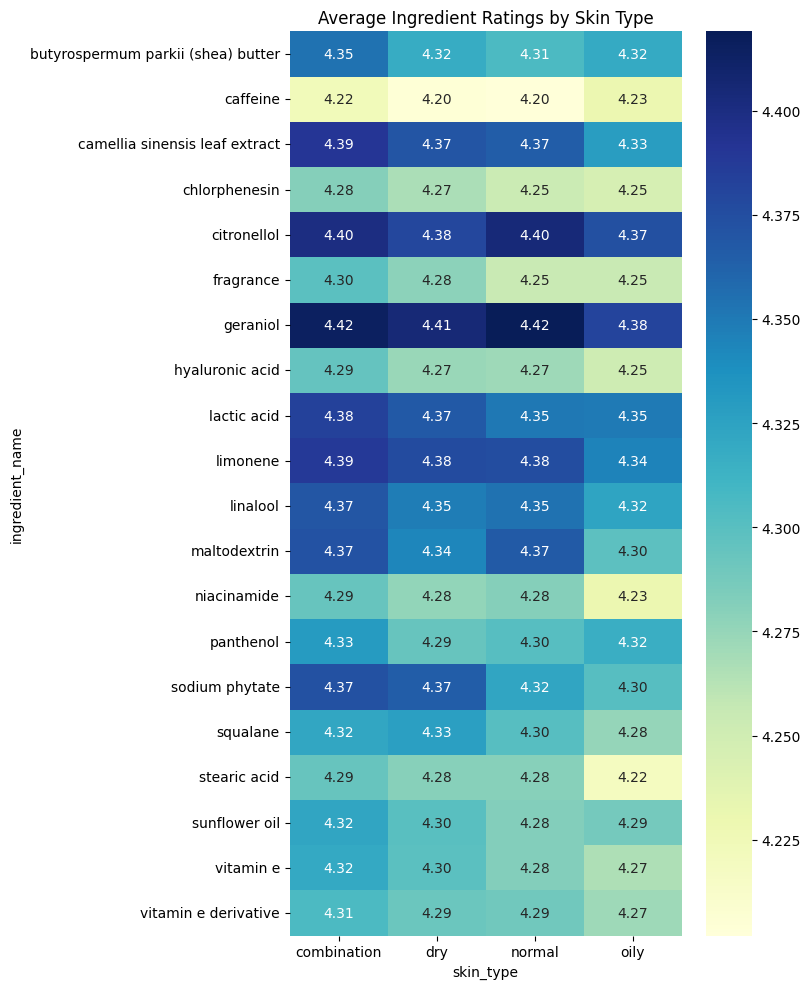

In [36]:
plt.figure(figsize=(8, 10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Ingredient Ratings by Skin Type")
plt.tight_layout()
plt.show()

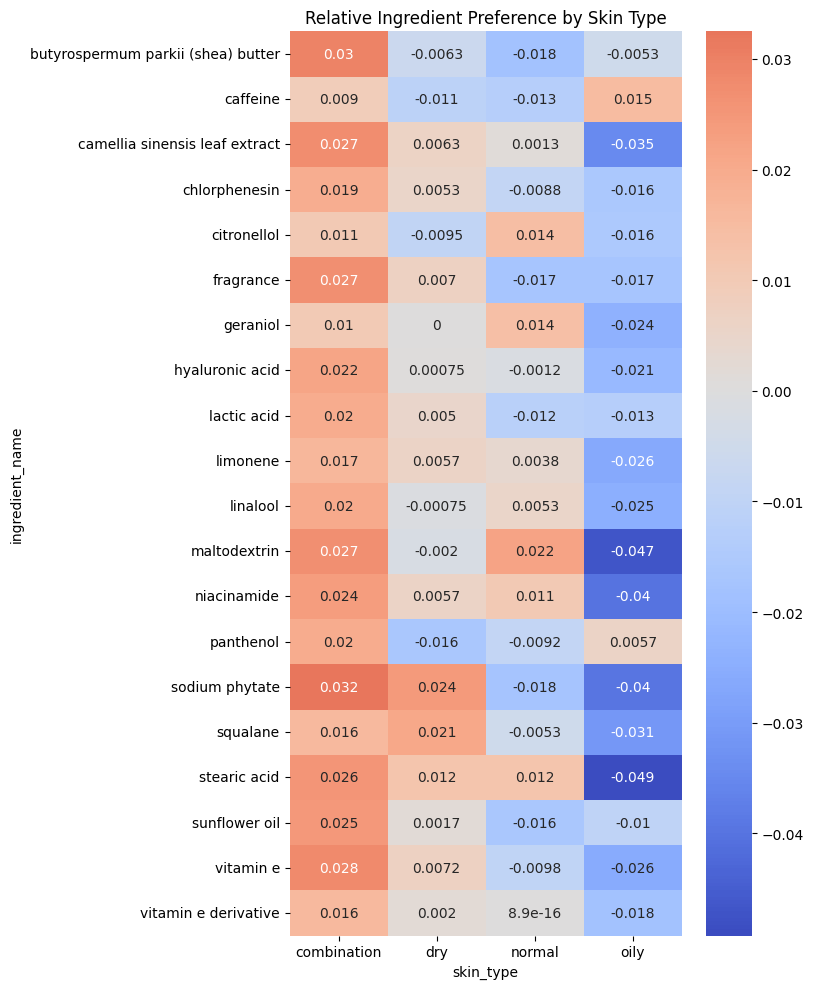

In [37]:
pivot_diff = pivot.subtract(pivot.mean(axis=1), axis=0)

plt.figure(figsize=(8,10))
sns.heatmap(pivot_diff, annot=True, cmap="coolwarm", center=0)
plt.title("Relative Ingredient Preference by Skin Type")
plt.tight_layout()
plt.show()